In [13]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

# Model to predict the live weight, carcass weight, price, total number of defects
from sklearn.model_selection import cross_validate, KFold
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer

# Model
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [14]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']
COLORS2 = ['#395144', '#4E6C50', '#AA8B56']

# Windows

In [15]:
RANDOM_STATE = 2210

In [16]:
# load preprocessed data files
beef = pd.read_csv('data/beef_preprocessed.csv')
df_win = pd.read_csv('data/beef_weather_windows.csv')
data =  beef.join(df_win)

In [17]:

models = [
    ("Dummy Regressor", "dummy", 0),
    ("ElasticNet", "elasticnet", 30),
    ("SVR", "svr", 20),
    ("Random Forest", "random_forest", 20),
    ("LightGBM", "lightgbm", 30),
    ("Hist Gradient Boosting", "hist_gradient_boosting", 20),
]


def build_model(model_type, params=None):
    params = params or {}

    if model_type == "dummy":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyRegressor(strategy="mean"))
        ])

    if model_type == "elasticnet":
        return Pipeline([
            ("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
            ("scaler", StandardScaler()),
            ("model", ElasticNet(
                alpha=params.get("alpha", 1.0),
                l1_ratio=params.get("l1_ratio", 0.5),
                max_iter=50000,
                random_state=RANDOM_STATE
            ))
        ])

    if model_type == "svr":
        return Pipeline([
            ("imputer", SimpleImputer(strategy=params.get("imputer_strategy", "median"))),
            ("scaler", StandardScaler()),
            ("model", SVR(
                C=params.get("C", 1.0),
                epsilon=params.get("epsilon", 0.1),
                gamma=params.get("gamma", "scale"),
                kernel="rbf"
            ))
        ])

    if model_type == "random_forest":
        return RandomForestRegressor(
            n_estimators=params.get("n_estimators", 300),
            max_depth=params.get("max_depth"),
            min_samples_leaf=params.get("min_samples_leaf", 1),
            max_features=params.get("max_features", 1.0),
            random_state=RANDOM_STATE,
            n_jobs=1
        )

    if model_type == "lightgbm":
        return LGBMRegressor(
            n_estimators=params.get("n_estimators", 300),
            learning_rate=params.get("learning_rate", 0.05),
            num_leaves=params.get("num_leaves", 31),
            max_depth=params.get("max_depth", -1),
            min_child_samples=params.get("min_child_samples", 20),
            subsample=params.get("subsample", 1.0),
            colsample_bytree=params.get("colsample_bytree", 1.0),
            reg_lambda=params.get("reg_lambda", 0.0),
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1
        )

    if model_type == "hist_gradient_boosting":
        return HistGradientBoostingRegressor(
            max_iter=params.get("max_iter", 300),
            learning_rate=params.get("learning_rate", 0.05),
            max_leaf_nodes=params.get("max_leaf_nodes", 31),
            l2_regularization=params.get("l2_regularization", 0.0),
            random_state=RANDOM_STATE
        )


def suggest_params(trial, model_type):
    if model_type == "elasticnet":
        return {
            "imputer_strategy": trial.suggest_categorical("imputer_strategy", ["median", "mean"]),
            "alpha": trial.suggest_float("alpha", 1e-4, 50, log=True),
            "l1_ratio": trial.suggest_float("l1_ratio", 0.05, 1.0),
        }

    if model_type == "svr":
        return {
            "imputer_strategy": trial.suggest_categorical("imputer_strategy", ["median", "mean"]),
            "C": trial.suggest_float("C", 0.1, 100, log=True),
            "epsilon": trial.suggest_float("epsilon", 0.01, 5, log=True),
            "gamma": trial.suggest_float("gamma", 1e-4, 1, log=True),
        }

    if model_type == "random_forest":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 500, step=50),
            "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 12]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_float("max_features", 0.3, 1.0),
        }

    if model_type == "lightgbm":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 150, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 64),
            "max_depth": trial.suggest_categorical("max_depth", [-1, 3, 5, 8]),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.7, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        }

    if model_type == "hist_gradient_boosting":
        return {
            "max_iter": trial.suggest_int("max_iter", 150, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 8, 64),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10, log=True),
        }

    return {}


def tune_model(model_type, X, y, n_trials):
    if n_trials == 0:
        return build_model(model_type), {}

    tuning_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = suggest_params(trial, model_type)
        model = build_model(model_type, params)
        cv = cross_validate(
            model,
            X,
            y,
            cv=tuning_cv,
            scoring="neg_mean_squared_error",
            n_jobs=1
        )
        return -cv["test_score"].mean()

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    return build_model(model_type, study.best_params), study.best_params


In [18]:
# Build splits for windows data.
# Rows are filtered per target, so animals with partial weather records can still be used.

targets = ['live weight', 'carcass weight', 'price', 'Total number of defects']
drop_features = ['kill date', 'kill year', 'kill month', 'Processing location', 'Presentation Grade', 'Grade',
                 'Teeth', 'Yield', 'Animal Type_num', 'Grade_num', 'Presentation Grade_num', 'Waste',
                 "price/kg", 'Animal Type', 'max_lag']#, 'Age']

X_full = data.drop(columns=[*drop_features, *targets], errors="ignore")
X_full = X_full.apply(pd.to_numeric, errors="coerce")
Y_full = data[targets].copy()

print("Complete cases:", pd.concat([X_full, Y_full], axis=1).dropna().shape[0])
print("Rows per target:")
display(Y_full.notna().sum().rename("n").to_frame())

Complete cases: 590
Rows per target:


,n
live weight,915
carcass weight,915
price,905
Total number of defects,915


In [20]:
# # -------------------------------------------------------------------
# # RUN EXPERIMENTS on windows
# # -------------------------------------------------------------------
# out_csv = "results/cv_results_on_animals_windows.csv"
# os.makedirs(os.path.dirname(out_csv), exist_ok=True)

# if os.path.exists(out_csv):
#     os.remove(out_csv)

# scoring = {
#     "MAE": "neg_mean_absolute_error",
#     "MSE": "neg_mean_squared_error",
# }

# cv_obj = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# for model_name, model_type, n_trials in models:
#     for target_name in Y_full.columns:
#         rows = []

#         for atype in ["cow", "steer", "heifer"]:
#             mask = (
#                 data["Animal Type"]
#                 .astype(str)
#                 .str.lower()
#                 .eq(atype)
#                 & Y_full[target_name].notna()
#             )
#             idx = X_full.index[mask]
#             if len(idx) < 5:
#                 continue

#             Xi = X_full.loc[idx]
#             Yi = Y_full.loc[idx, target_name]

#             model, best_params = tune_model(model_type, Xi, Yi, n_trials)

#             cv = cross_validate(
#                 model,
#                 Xi,
#                 Yi,
#                 cv=cv_obj,
#                 scoring=scoring,
#                 return_train_score=True,
#                 n_jobs=1,
#             )

#             rows += [
#                 {
#                     "model_name": model_name,
#                     "animal_type": atype,
#                     "target": target_name,
#                     "measure (MAE/MSE)": m,
#                     "Cross-validation": i + 1,
#                     "evaluated_on (Train/Test)": s.capitalize(),
#                     "Error": -cv[f"{s}_{m}"][i],
#                     "n_rows": len(Xi),
#                     "n_missing_feature_values": int(Xi.isna().sum().sum()),
#                     "best_params": str(best_params),
#                 }
#                 for m in ("MAE", "MSE")
#                 for s in ("train", "test")
#                 for i in range(cv_obj.get_n_splits())
#             ]

#         if rows:
#             pd.DataFrame(rows).to_csv(
#                 out_csv,
#                 mode="a",
#                 index=False,
#                 header=not os.path.exists(out_csv),
#             )

#         print("Completed", model_name, "|", target_name)

In [21]:
df_res = pd.read_csv("results/cv_results_on_animals_windows.csv")
df_res = df_res[df_res["evaluated_on (Train/Test)"].eq("Test")].copy()
df_res = df_res[df_res["measure (MAE/MSE)"].eq("MSE")].copy()
df_res = df_res[df_res["animal_type"] != "All"].copy()
df_res = df_res[df_res["target"] != "Total number of defects"].copy()

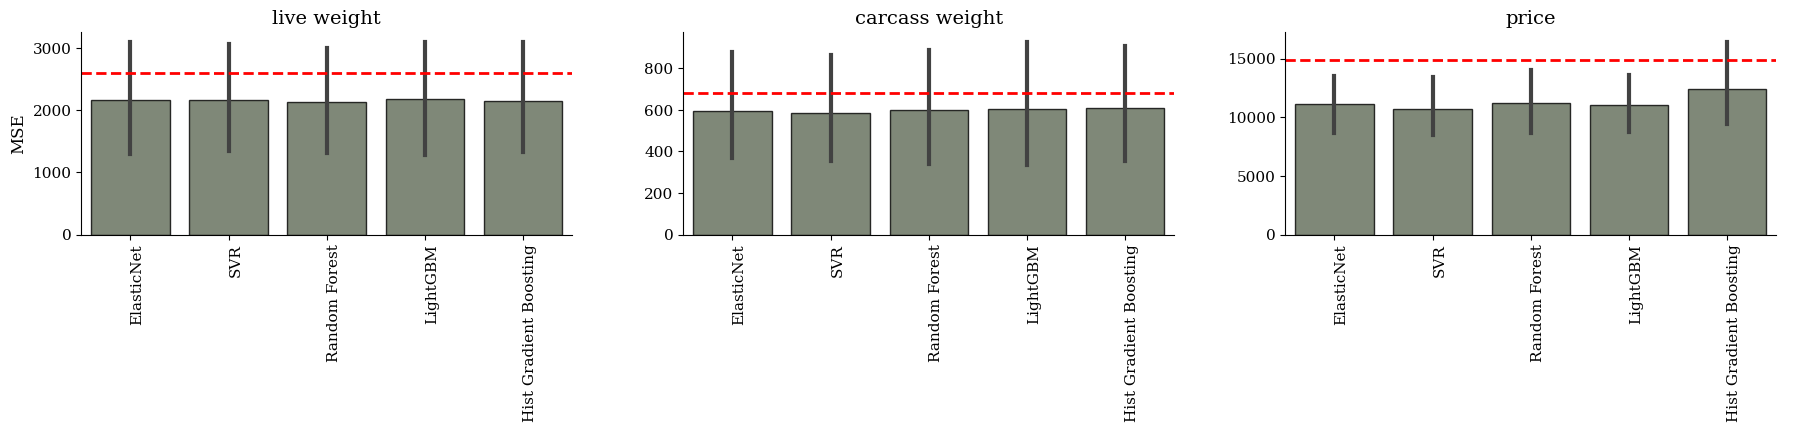

In [22]:
# Overall best models
g = sns.catplot(data=df_res[df_res['model_name'] != 'Dummy Regressor'], kind="bar", x="model_name", col="target", y="Error", 
                sharey=False, color=COLORS[0], alpha=0.8, edgecolor="black", height=3, aspect=2)
g.set_xticklabels(rotation=90, ha='right', rotation_mode='anchor')
g.set_axis_labels("", "MSE")
for tgt, ax in g.axes_dict.items():
    ax.set_title(f"{tgt}")

# baseline per target
baseline_means = df_res[df_res['model_name'] == 'Dummy Regressor'].groupby("target")["Error"].mean()
for ax in g.axes.flat:
    target = ax.get_title().split(" = ")[-1]
    ax.axhline(y=baseline_means[target], color="red", linestyle="--")